# Figure 6 Plotting Notebook
## Multi-Task Analysis with Bootstrap Confidence Intervals

This notebook generates Figure 6 style plots for continual learning experiments with:
- Bootstrap confidence intervals (distribution-free)
- Example styling with coolors palette
- Grey dotted lines marking level transitions
- Live plotting (no file saving)

**Usage**: Run each cell to generate plots for different tasks. Change the `data_folder` parameter to compare different experimental runs.


In [37]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from typing import Dict, List
from pathlib import Path

# Import the Coolors palette (same as example)
coolors_palette = [
    '#ff595e',  # Vibrant red
    '#ffca3a',  # Bright yellow  
    '#8ac926',  # Fresh green
    '#1982c4',  # Deep blue
    '#6a4c93'   # Rich purple
]

# Define consistent color mapping for each topology type
topology_colors = {
    'standard_mlp': '#ff595e',    # Vibrant red
    'hybrid': '#ffca3a',          # Bright yellow
    'modular': '#8ac926',         # Fresh green
    'small_world': '#1982c4'      # Deep blue
}

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [38]:
# UTILITY FUNCTIONS
# ============================================================================

def load_topology_data(data_folder: str) -> Dict:
    """Load topology data from specified folder (recursively searches through noise_level/network_size structure)."""
    print(f"🔄 Loading data from {data_folder} folder...")
    
    topology_groups = {}
    base_path = Path(data_folder)  # Data folders are in current directory
    
    if not base_path.exists():
        print(f"❌ Folder {data_folder} not found!")
        return {}
    
    # Check if this is a specific subfolder (contains noise level and/or network size)
    # If so, search only in this specific folder, not recursively
    if any(part.startswith(('N00', 'S')) for part in base_path.parts):
        # This is a specific subfolder, search for experiment directories inside it
        search_paths = [run_dir for run_dir in base_path.iterdir() if run_dir.is_dir() and run_dir.name.startswith(('HYB_', 'MOD_', 'SW_', 'STANDARD_MLP_'))]
        print(f"   📁 Searching in specific subfolder: {base_path}")
    else:
        # This is a task folder, search recursively through all subfolders
        search_paths = [run_dir for run_dir in base_path.rglob("*") if run_dir.is_dir() and run_dir.name.startswith(('HYB_', 'MOD_', 'SW_', 'STANDARD_MLP_'))]
        print(f"   📁 Searching recursively in task folder: {base_path}")
    
    # Find all experiment directories
    for search_path in search_paths:
            try:
                # Parse run name to extract topology
                run_name = search_path.name
                if run_name.startswith('HYB_'):
                    topology = 'hybrid'
                elif run_name.startswith('MOD_'):
                    topology = 'modular'
                elif run_name.startswith('SW_'):
                    topology = 'small_world'
                elif run_name.startswith('STANDARD_MLP_'):
                    topology = 'standard_mlp'
                else:
                    continue
                
                # Load episode data
                episode_file = search_path / "data" / "episode_data.csv"
                if episode_file.exists():
                    episode_data = pd.read_csv(episode_file)
                    
                    if 'episode_return_raw' in episode_data.columns:
                        rewards = episode_data['episode_return_raw']
                        
                        # Group episodes by iteration (every 2 episodes) and calculate mean per iteration
                        iteration_rewards = []
                        for i in range(0, len(rewards), 2):
                            if i + 1 < len(rewards):
                                iteration_mean = rewards.iloc[i:i+2].mean()
                                iteration_rewards.append(iteration_mean)
                            elif i < len(rewards):
                                iteration_rewards.append(rewards.iloc[i])
                        
                        if topology not in topology_groups:
                            topology_groups[topology] = []
                        topology_groups[topology].append(np.array(iteration_rewards))
                        
            except Exception as e:
                print(f"⚠️ Error loading {search_path}: {e}")
                continue
    
    print(f"✅ Loaded data for {len(topology_groups)} topology types")
    for topology, data_list in topology_groups.items():
        print(f"   {topology}: {len(data_list)} runs")
    
    return topology_groups

def calculate_bootstrap_confidence_intervals(data_arrays: List[np.ndarray], confidence: float = 0.95, n_bootstrap: int = 1000) -> Dict:
    """Calculate bootstrap confidence intervals (distribution-free)."""
    if not data_arrays:
        return {}
    
    # Stack arrays
    stacked = np.vstack(data_arrays)
    mean = np.mean(stacked, axis=0)
    std = np.std(stacked, axis=0, ddof=1)
    var = np.var(stacked, axis=0, ddof=1)
    
    # Bootstrap confidence intervals
    n_seeds = len(data_arrays)
    n_iterations = stacked.shape[1]
    
    bootstrap_means = []
    for _ in range(n_bootstrap):
        # Resample with replacement
        bootstrap_indices = np.random.choice(n_seeds, size=n_seeds, replace=True)
        bootstrap_data = stacked[bootstrap_indices]
        bootstrap_mean = np.mean(bootstrap_data, axis=0)
        bootstrap_means.append(bootstrap_mean)
    
    bootstrap_means = np.array(bootstrap_means)
    
    # Calculate percentiles for confidence intervals
    alpha = 1 - confidence
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    lower_bound = np.percentile(bootstrap_means, lower_percentile, axis=0)
    upper_bound = np.percentile(bootstrap_means, upper_percentile, axis=0)
    
    return {
        'mean': mean,
        'std': std,
        'var': var,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_seeds': len(data_arrays),
        'cv': std / np.abs(mean + 1e-8)
    }

def apply_window_smoothing(data: np.ndarray, window: int = 5) -> np.ndarray:
    """Apply window smoothing to data."""
    if len(data) < window:
        return data
    
    smoothed = np.convolve(data, np.ones(window)/window, mode='valid')
    # Pad the beginning to maintain length
    padding = np.full(window-1, smoothed[0])
    return np.concatenate([padding, smoothed])

def prepare_bootstrap_figure6_data(topology_groups: Dict) -> Dict:
    """Prepare data for Figure6 plots with bootstrap confidence intervals."""
    figure6_data = {}
    
    for topology_key, group in topology_groups.items():
        if not group:
            continue
            
        # Filter out empty runs first
        valid_runs = [run_data for run_data in group if len(run_data) > 0]
        if not valid_runs:
            continue
            
        # Find maximum iterations across all valid runs
        max_iterations = max(len(run_data) for run_data in valid_runs)
        
        # Pad shorter runs with their last value
        padded_rewards = []
        for run_data in valid_runs:
            if len(run_data) < max_iterations:
                # Pad with last value
                padded = np.pad(run_data, (0, max_iterations - len(run_data)), mode='edge')
            else:
                padded = run_data[:max_iterations]
            
            # Apply smoothing
            smoothed = apply_window_smoothing(padded, window=5)
            padded_rewards.append(smoothed)
        
        # Calculate bootstrap confidence intervals
        stats = calculate_bootstrap_confidence_intervals(padded_rewards)
        
        figure6_data[topology_key] = {
            'iterations': np.arange(1, max_iterations + 1),
            'mean_rewards': stats['mean'],
            'std_rewards': stats['std'],
            'lower_bound': stats['lower_bound'],
            'upper_bound': stats['upper_bound'],
            'cv': stats['cv'],
            'topology_type': topology_key.replace('_', ' ').title(),
            'num_seeds': stats['n_seeds']
        }
    
    return figure6_data

print("✅ Utility functions defined successfully!")


✅ Utility functions defined successfully!


## Cell 1: Cartpole Analysis

Change the `data_folder` parameter to compare different experimental runs.


🔄 Running Cartpole Figure 6 analysis...
🔄 Loading data from cartpole/N0002/S128 folder...
   📁 Searching in specific subfolder: cartpole/N0002/S128
✅ Loaded data for 4 topology types
   small_world: 4 runs
   hybrid: 4 runs
   modular: 4 runs
   standard_mlp: 3 runs


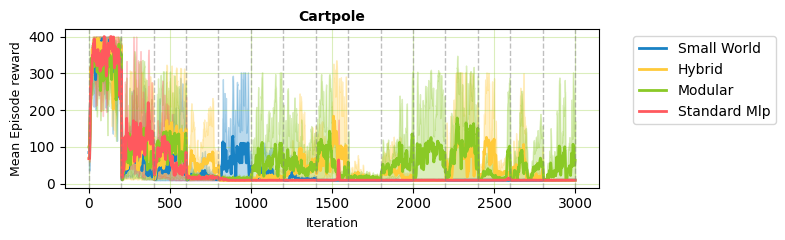

✅ Cartpole plot generated from cartpole/N0002/S128 folder!


In [39]:
# CARTPOLE FIGURE 6 ANALYSIS
# ============================================================================

def plot_cartpole_figure6(data_folder="cartpole"):
    """Plot Figure 6 for Cartpole task from specified data folder."""
    
    # Set the color palette for matplotlib
    plt.style.use('default')
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=coolors_palette)
    
    # Load data from specified folder
    topology_groups = load_topology_data(data_folder)
    if not topology_groups:
        print(f"❌ No data found in {data_folder}")
        return
    
    figure6_data = prepare_bootstrap_figure6_data(topology_groups)
    
    # Create figure with same dimensions as example
    plt.figure(figsize=(4*2, 2.5))
    
    # Plot each topology with consistent colors
    for topology_key, data in figure6_data.items():
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        # Use consistent color mapping for each topology type
        color = topology_colors.get(topology_key, '#6a4c93')  # Default purple if not found
        
        # Plot the mean line
        plt.plot(iterations, mean_rewards, color=color, linewidth=2, 
                label=f"{data['topology_type']}")
        
        # Plot bootstrap confidence intervals
        plt.fill_between(iterations, lower_bound, upper_bound, alpha=0.3, 
                        color=color)
    
    # Add vertical dashed lines at steps 0, 200, 400, 600, etc. (same as example)
    if len(figure6_data) > 0:
        max_iterations = max(data['iterations'][-1] for data in figure6_data.values())
        vertical_steps = list(range(0, int(max_iterations) + 1, 200))
        for step in vertical_steps:
            plt.axvline(x=step, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Customize the plot
    plt.xlabel('Iteration', fontsize=9, color='black')
    plt.ylabel('Mean Episode reward', fontsize=9, color='black')
    plt.title(f'Cartpole', fontsize=10, color='black', fontweight='bold')
    plt.grid(True, alpha=0.3, color=coolors_palette[2])
    plt.gca().set_facecolor('white')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Cartpole plot generated from {data_folder} folder!")

# Run Cartpole analysis
print("🔄 Running Cartpole Figure 6 analysis...")
# Examples:
# plot_cartpole_figure6()  # Uses default: "cartpole" (all experiments)
# plot_cartpole_figure6(data_folder="cartpole/N0001/S128")  # Specific noise level and network size
# plot_cartpole_figure6(data_folder="cartpole/N0002")  # Specific noise level only
plot_cartpole_figure6(data_folder="cartpole/N0002/S128")  # Change this to analyze different subfolders


## Cell 2: Acrobot Analysis

Change the `data_folder` parameter to compare different experimental runs.


🔄 Running Acrobot Figure 6 analysis...
🔄 Loading data from acrobot/N0001/S128 folder...
   📁 Searching in specific subfolder: acrobot/N0001/S128


✅ Loaded data for 4 topology types
   modular: 3 runs
   small_world: 2 runs
   standard_mlp: 2 runs
   hybrid: 2 runs


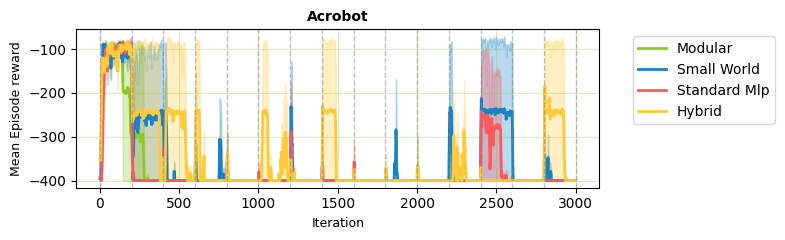

✅ Acrobot plot generated from acrobot/N0001/S128 folder!


In [40]:
# ACROBOT FIGURE 6 ANALYSIS
# ============================================================================

def plot_acrobot_figure6(data_folder="acrobot"):
    """Plot Figure 6 for Acrobot task from specified data folder."""
    
    # Set the color palette for matplotlib
    plt.style.use('default')
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=coolors_palette)
    
    # Load data from specified folder
    topology_groups = load_topology_data(data_folder)
    if not topology_groups:
        print(f"❌ No data found in {data_folder}")
        return
    
    figure6_data = prepare_bootstrap_figure6_data(topology_groups)
    
    # Create figure with same dimensions as example
    plt.figure(figsize=(4*2, 2.5))
    
    # Plot each topology with different colors from the palette
    for topology_key, data in figure6_data.items():
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        # Use consistent color mapping for each topology type
        color = topology_colors.get(topology_key, '#6a4c93')  # Default purple if not found
        
        # Plot the mean line
        plt.plot(iterations, mean_rewards, color=color, linewidth=2, 
                label=f"{data['topology_type']}")
                # label=f"{data['topology_type']} (n={data['num_seeds']})")
        
        # Plot bootstrap confidence intervals
        plt.fill_between(iterations, lower_bound, upper_bound, alpha=0.3, 
                        color=color)
    
    # Add vertical dashed lines at steps 0, 200, 400, 600, etc. (same as example)
    if len(figure6_data) > 0:
        max_iterations = max(data['iterations'][-1] for data in figure6_data.values())
        vertical_steps = list(range(0, int(max_iterations) + 1, 200))
        for step in vertical_steps:
            plt.axvline(x=step, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Customize the plot
    plt.xlabel('Iteration', fontsize=9, color='black')
    plt.ylabel('Mean Episode reward', fontsize=9, color='black')
    plt.title(f'Acrobot', fontsize=10, color='black', fontweight='bold')
    plt.grid(True, alpha=0.3, color=coolors_palette[2])
    plt.gca().set_facecolor('white')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Acrobot plot generated from {data_folder} folder!")

# Run Acrobot analysis
print("🔄 Running Acrobot Figure 6 analysis...")
plot_acrobot_figure6(data_folder="acrobot/N0001/S128")  # Change folder here to compare different runs


## Cell 3: Lunarlander Analysis

Change the `data_folder` parameter to compare different experimental runs.


🔄 Running Lunarlander Figure 6 analysis...
🔄 Loading data from lunarlander/N0002/S128 folder...
   📁 Searching in specific subfolder: lunarlander/N0002/S128
✅ Loaded data for 4 topology types
   hybrid: 4 runs
   modular: 4 runs
   small_world: 2 runs
   standard_mlp: 2 runs


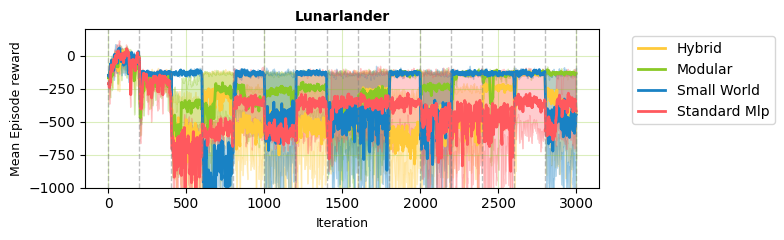

✅ Lunarlander plot generated from lunarlander/N0002/S128 folder!


In [41]:
# LUNARLANDER FIGURE 6 ANALYSIS
# ============================================================================

def plot_lunarlander_figure6(data_folder="lunarlander"):
    """Plot Figure 6 for Lunarlander task from specified data folder."""
    
    # Set the color palette for matplotlib
    plt.style.use('default')
    plt.rcParams['axes.prop_cycle'] = plt.cycler(color=coolors_palette)
    
    # Load data from specified folder
    topology_groups = load_topology_data(data_folder)
    if not topology_groups:
        print(f"❌ No data found in {data_folder}")
        return
    
    figure6_data = prepare_bootstrap_figure6_data(topology_groups)
    
    # Create figure with same dimensions as example
    # plt.figure(figsize=(3.15*1.5, 1.97))
    plt.figure(figsize=(4*2, 2.5))
    
    # Plot each topology with different colors from the palette
    for topology_key, data in figure6_data.items():
        iterations = data['iterations']
        mean_rewards = data['mean_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        # Use consistent color mapping for each topology type
        color = topology_colors.get(topology_key, '#6a4c93')  # Default purple if not found
        
        # Plot the mean line
        plt.plot(iterations, mean_rewards, color=color, linewidth=2, 
                label=f"{data['topology_type']}")
        
        # Plot bootstrap confidence intervals
        plt.fill_between(iterations, lower_bound, upper_bound, alpha=0.3, 
                        color=color)
    
    # Add vertical dashed lines at steps 0, 200, 400, 600, etc. (same as example)
    if len(figure6_data) > 0:
        max_iterations = max(data['iterations'][-1] for data in figure6_data.values())
        vertical_steps = list(range(0, int(max_iterations) + 1, 200))
        for step in vertical_steps:
            plt.axvline(x=step, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Customize the plot
    plt.xlabel('Iteration', fontsize=9, color='black')
    plt.ylabel('Mean Episode reward', fontsize=9, color='black')
    plt.ylim(-1000, 200)
    plt.title(f'Lunarlander', fontsize=10, color='black', fontweight='bold')
    plt.grid(True, alpha=0.3, color=coolors_palette[2])
    plt.gca().set_facecolor('white')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Lunarlander plot generated from {data_folder} folder!")

# Run Lunarlander analysis
print("🔄 Running Lunarlander Figure 6 analysis...")
plot_lunarlander_figure6(data_folder="lunarlander/N0002/S128")  # Change folder here to compare different runs
